# Round-wise Decisive-Disclosure Timing (GPT)

For each deliberation result, finds the **first round in which any decisive feature was
disclosed** (`first_decisive_round`), then reports what fraction of decisive disclosures
happen in Round 1, Round 2, and Round 3 ("thereafter"), per mechanism.

Results source: `results/gpt/`.

Note on methodology: the pipeline stores a precomputed `first_decisive_round` field in
each result record, but it is **not populated for the `free_debate` baseline**
(`engine.py::_run_free_debate` never sets it — see `_run_forced_sharing` vs.
`_run_free_debate`). This notebook recomputes it directly from `rounds[].agent_turns[].features_disclosed`
against each scenario's decisive-feature set (from `data/scenarios.json`), so the same
logic applies uniformly across mechanisms. For `forced_sharing`, which has no round
structure (`rounds=[]`, one-shot disclosure), Round 1 is used whenever any decisive
feature was surfaced. `no_comm` never discloses, so it is always "never surfaced".

In [14]:
import os
import json
import collections

import pandas as pd
import matplotlib.pyplot as plt

# Paths — resolved relative to this notebook's location, so it works regardless of user/host.
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
BASE_PATH = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..'))  # IncentivizingRevelation/
RESULTS_PATH = os.path.join(BASE_PATH, 'results', 'gpt')
SCENARIOS_PATH = os.path.join(BASE_PATH, 'data', 'scenarios.json')

MECHANISMS = [
    'uniform', 'uniform_no_cost',
    'contribution', 'contribution_no_cost', 'contribution_oracle', 'counterfactual_contribution',
    'hybrid', 'stake', 'bid_to_speak',
    'free_debate', 'forced_sharing', 'no_comm',
]

print(f"Base path: {BASE_PATH}")
print(f"Results path: {RESULTS_PATH}")


Base path: /common/adinara/work/llm_delib/IncentivizingRevelation
Results path: /common/adinara/work/llm_delib/IncentivizingRevelation/results/gpt


## 1. Load decisive-feature map and raw results

In [15]:
# scenario_id -> set of decisive feature names
with open(SCENARIOS_PATH) as f:
    _scenarios_raw = json.load(f)
_scenario_list = _scenarios_raw.get('scenarios', _scenarios_raw if isinstance(_scenarios_raw, list) else [])

decisive_map = {
    s['id']: {fname for fname, finfo in s.get('full_view', {}).items() if finfo.get('tag') == 'decisive'}
    for s in _scenario_list
}
print(f"Loaded decisive-feature sets for {len(decisive_map)} scenarios")


Loaded decisive-feature sets for 60 scenarios


In [16]:
def find_results_file(mech_path, mechanism):
    """Results live either directly in the mechanism dir or under a timestamp subdir."""
    direct = os.path.join(mech_path, f'results_{mechanism}.json')
    if os.path.exists(direct):
        return direct
    if not os.path.isdir(mech_path):
        return None
    for entry in sorted(os.listdir(mech_path)):
        sub = os.path.join(mech_path, entry)
        if os.path.isdir(sub):
            cand = os.path.join(sub, f'results_{mechanism}.json')
            if os.path.exists(cand):
                return cand
    return None

interaction_data = {}
for mech in MECHANISMS:
    mech_path = os.path.join(RESULTS_PATH, mech)
    rf = find_results_file(mech_path, mech)
    if rf is None:
        print(f"WARNING: no results file found for {mech}")
        continue
    with open(rf) as f:
        interaction_data[mech] = json.load(f)
    print(f"{mech:30s} n={len(interaction_data[mech]):4d}  {os.path.relpath(rf, BASE_PATH)}")


uniform                        n= 300  results/gpt/uniform/20260422_151158/results_uniform.json
uniform_no_cost                n= 300  results/gpt/uniform_no_cost/results_uniform_no_cost.json
contribution                   n= 300  results/gpt/contribution/20260422_151218/results_contribution.json
contribution_no_cost           n= 300  results/gpt/contribution_no_cost/results_contribution_no_cost.json
contribution_oracle            n= 300  results/gpt/contribution_oracle/20260422_151223/results_contribution_oracle.json
counterfactual_contribution    n= 300  results/gpt/counterfactual_contribution/20260422_151228/results_counterfactual_contribution.json
hybrid                         n= 300  results/gpt/hybrid/20260422_151925/results_hybrid.json
stake                          n= 300  results/gpt/stake/20260422_151305/results_stake.json
bid_to_speak                   n= 300  results/gpt/bid_to_speak/20260422_151312/results_bid_to_speak.json
free_debate                    n= 300  results/g

## 2. Recompute `first_decisive_round`, bucket by round, and build the table

The table includes one row per mechanism plus a pooled `ALL (pooled, excl. no_comm)` row — `no_comm` never discloses anything, so it is excluded from the pooled figure.

In [17]:
def first_decisive_round(result, decisive_map):
    """First round any decisive feature appears in features_disclosed, or None if never."""
    decisive_set = decisive_map.get(result['scenario_id'], set())
    if not decisive_set:
        return None

    rounds = result.get('rounds') or []
    if rounds:
        for rnd in rounds:
            disclosed = {
                feat
                for turn in rnd.get('agent_turns', [])
                for feat in turn.get('features_disclosed', {})
            }
            if decisive_set & disclosed:
                return rnd['round_num']
        return None

    # No round structure (forced_sharing's one-shot disclosure) — fall back to the
    # precomputed surfaced-features list.
    return 1 if result.get('decisive_features_surfaced') else None


def round_wise_breakdown(interactions, decisive_map, cap_round=3):
    """Returns (Counter of {round_bucket: count}, n_surfaced, n_total).

    round_bucket is 1..cap_round-1 as-is, and cap_round for cap_round or later.
    """
    counter = collections.Counter()
    n_total = len(interactions)
    n_surfaced = 0
    for r in interactions:
        fr = first_decisive_round(r, decisive_map)
        if fr is None:
            continue
        n_surfaced += 1
        bucket = fr if fr < cap_round else cap_round
        counter[bucket] += 1
    return counter, n_surfaced, n_total


def make_row(label, counter, n_surfaced, n_total, cap_round):
    row = {
        'mechanism': label,
        'n_total': n_total,
        'n_surfaced': n_surfaced,
        'pct_never_surfaced': round(100 * (n_total - n_surfaced) / n_total, 1) if n_total else float('nan'),
    }
    for k in range(1, cap_round + 1):
        col = f'round_{k}_pct' if k < cap_round else f'round_{k}_plus_pct'
        row[col] = round(100 * counter.get(k, 0) / n_surfaced, 1) if n_surfaced else float('nan')
    return row


CAP_ROUND = 3  # GPT runs use 3 rounds; round 3 bucket == "thereafter"

rows = []
pooled_counter = collections.Counter()
pooled_n_surfaced = 0
pooled_n_total = 0

for mech in MECHANISMS:
    interactions = interaction_data.get(mech, [])
    if not interactions:
        continue
    counter, n_surfaced, n_total = round_wise_breakdown(interactions, decisive_map, cap_round=CAP_ROUND)
    rows.append(make_row(mech, counter, n_surfaced, n_total, CAP_ROUND))
    if mech != 'no_comm':
        pooled_counter.update(counter)
        pooled_n_surfaced += n_surfaced
        pooled_n_total += n_total

POOLED_LABEL = 'ALL (pooled, excl. no_comm)'
rows.append(make_row(POOLED_LABEL, pooled_counter, pooled_n_surfaced, pooled_n_total, CAP_ROUND))

round_wise_df = pd.DataFrame(rows).set_index('mechanism')
round_wise_df


,n_total,n_surfaced,pct_never_surfaced,round_1_pct,round_2_pct,round_3_plus_pct
mechanism,,,,,,
uniform,300,133,55.7,35.3,51.1,13.5
uniform_no_cost,300,260,13.3,80.4,18.1,1.5
contribution,300,285,5.0,89.1,10.9,0.0
contribution_no_cost,300,296,1.3,94.3,5.7,0.0
contribution_oracle,300,289,3.7,86.2,12.5,1.4
counterfactual_contribution,300,256,14.7,75.0,22.3,2.7
hybrid,300,201,33.0,49.8,44.3,6.0
stake,300,109,63.7,22.0,58.7,19.3
bid_to_speak,300,221,26.3,61.5,34.8,3.6


## 3. Headline sentence

In [18]:
pooled_row = round_wise_df.loc[POOLED_LABEL]
r1, r2, r3plus = pooled_row['round_1_pct'], pooled_row['round_2_pct'], pooled_row['round_3_plus_pct']

print(f"Pooled across {pooled_n_surfaced}/{pooled_n_total} results where a decisive feature was ever surfaced:\n")
print(f"Round-wise, {r1:.1f}% of decisive disclosures occur in Round 1, "
      f"{r2:.1f}% in Round 2, and {r3plus:.1f}% thereafter.")


Pooled across 2650/3300 results where a decisive feature was ever surfaced:

Round-wise, 78.9% of decisive disclosures occur in Round 1, 18.3% in Round 2, and 2.8% thereafter.


## 4. Visualization

The pooled row is pinned to the top (bold label, separated by a rule) above the per-mechanism rows, which are sorted by Round-1 share.

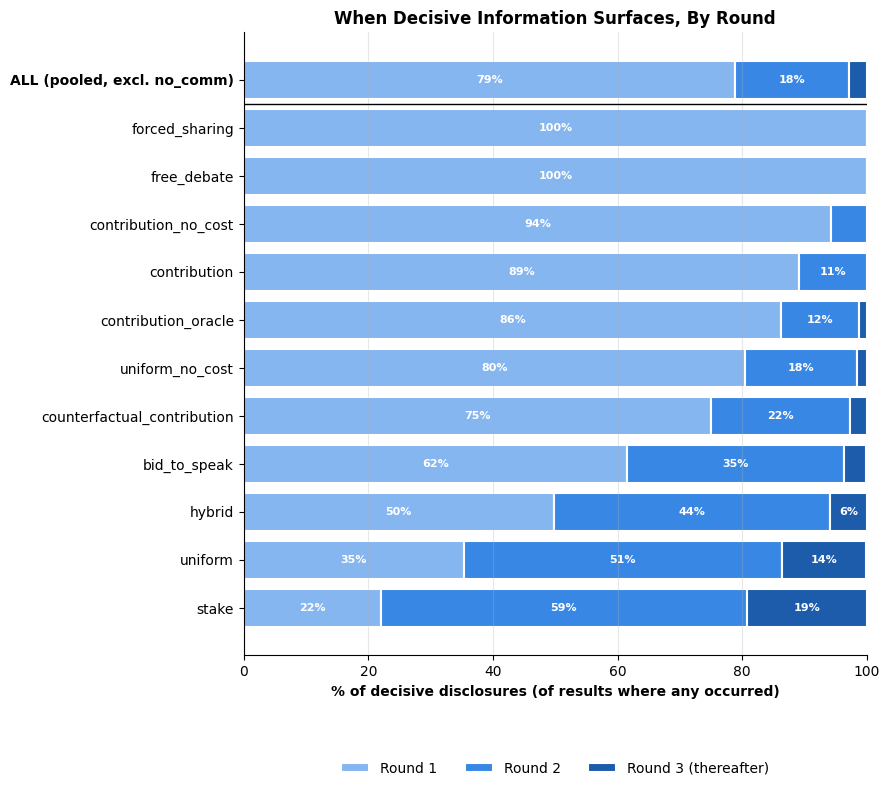

In [19]:
# Ordinal ramp (blue, light -> dark) for the three round buckets — fixed order, never cycled.
ROUND_COLORS = ['#86b6ef', '#3987e5', '#1c5cab']  # Round 1, Round 2, Round 3+ (thereafter)
ROUND_LABELS = ['Round 1', 'Round 2', 'Round 3 (thereafter)']
pct_cols = ['round_1_pct', 'round_2_pct', 'round_3_plus_pct']

mech_df = round_wise_df.drop(index=POOLED_LABEL).dropna(subset=['round_1_pct']).copy()
mech_df = mech_df.sort_values('round_1_pct', ascending=True)
plot_df = pd.concat([mech_df, round_wise_df.loc[[POOLED_LABEL]]])  # pooled row last -> plotted at top

fig, ax = plt.subplots(figsize=(9, 0.5 * len(plot_df) + 2))

left = pd.Series(0.0, index=plot_df.index)
for col, color, label in zip(pct_cols, ROUND_COLORS, ROUND_LABELS):
    values = plot_df[col].fillna(0.0)
    ax.barh(plot_df.index, values, left=left, color=color, edgecolor='white',
            linewidth=1.5, label=label)
    for y, (v, l) in enumerate(zip(values, left)):
        if v >= 6:  # selective direct labels — skip tiny slivers
            ax.text(l + v / 2, y, f'{v:.0f}%', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    left = left + values

# Separate the pooled row from the individual mechanisms with a rule + bold label
pooled_y = len(plot_df) - 1
ax.axhline(pooled_y - 0.5, color='black', linewidth=1.0)
ax.get_yticklabels()[pooled_y].set_fontweight('bold')  # mutate in place, no set_yticklabels() needed

ax.set_xlim(0, 100)
ax.set_xlabel('% of decisive disclosures (of results where any occurred)', fontsize=10, fontweight='bold')
ax.set_title('When Decisive Information Surfaces, By Round', fontsize=12, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
ax.grid(axis='x', alpha=0.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'round_wise_decisive_disclosure.png'), dpi=300, bbox_inches='tight')
plt.show()
